In [1]:
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import copy
import math
import numpy as np
from torchvision import datasets, transforms
import torch
from numpy import *

from utils.sampling import mnist_iid_cluster, mnist_noniid_cluster, cifar_iid,cifar_noniid_cluster, cifar_noniid_cluster_varying_users
from utils.options import args_parser
from models_v4.Update import LocalUpdate,ClusterDetect #, Scaffold
from models_v4.Nets import MLP, CNNMnist, CNNCifar, LeNet, CNNMnist2
from models_v4.Fed import FedAvg_vectorization, FedMult, FedAvg_noscale, FedAvg_gradient2
from models_v4.Fed import FedQAvg, FedBrea, Quantization, Quantization_Finite, my_score, my_score_Finite
from models_v4.test import test_img
from scipy.linalg import null_space


%load_ext autoreload
%autoreload 2
class my_argument:    
    epochs = 200   #"rounds of training"
    num_users = 5 # "number of users: K"
    frac = 0.5 #"the fraction of clients: C"
    local_ep=5 #"the number of local epochs: E"
    local_bs=125 #"local batch size: B"
    bs=128 #"test batch size"
    lr=0.0005 #"learning rate"
    momentum=0.5 # "SGD momentum (default: 0.5)"
    split='user' # "train-test split type, user or sample"

    # model arguments
    model = 'cnn'
    kernel_num=9 #, help='number of each kind of kernel')
    kernel_sizes='3,4,5' #  help='comma-separated kernel size to use for convolution')
    norm='batch_norm' #, help="batch_norm, layer_norm, or None")
    num_filters=32 #, help="number of filters for conv nets")
    max_pool='True' #help="Whether use max pooling rather than strided convolutions")

    # other arguments
    dataset='cifar' #, help="name of dataset")
    iid=0
    num_classes=10#, help="number of classes")
    num_channels=3#, help="number of channels of images")
    gpu=3#, help="GPU ID, -1 for CPU")
    stopping_rounds=10#, help='rounds of early stopping')
    verbose='False'#, help='verbose print')
    seed=1#, help='random seed (default: 1)')
    cluster=5
    opt='ADAM'
args = my_argument()
#args.device = torch.device('cuda:{}'.format(args.gpu) if torch.cuda.is_available() and args.gpu != -1 else 'cpu')
print(args.epochs)
#np.random.seed(1)


/usr/lib/python3/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/usr/lib/python3/dist-packages/torchvision/image.so: undefined symbol: _ZN3c104cuda9SetDeviceEi'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


200


In [2]:
# load dataset and split users
u=[4,5,8,12,15]
u=[3,4,4,4,10]
u=[10,4,4,4,3]
u=[5,5,5,5,5]
u=[15,3,3,2,2]
#u=[5,5,5,5,5]
#u=[2,5,5,6,7]
#u=[2,3,4,4,12]
#u=[5,5,5,5,5]
#u=[2,2,3,3,15]
if args.dataset == 'mnist':
    trans_mnist = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    dataset_train = datasets.MNIST('./data/mnist/', train=True, download=True, transform=trans_mnist)
    dataset_test = datasets.MNIST('./data/mnist/', train=False, download=True, transform=trans_mnist)
    count=0
    #print(len(dataset_train))
    dict_users=[] #2D array in each row, users of a particular cluster
    train_data=[]
    test_data=[]
    for j in range(args.cluster):
        train_data.append([])
        test_data.append([])
        dict_users.append([])
    for j in range(len(dataset_train)):
        data,label=j
        if (label==0) | (label==1):
            train_data[0].append(dataset_train[j])
        elif (label==2) | (label==3):
            train_data[1].append(dataset_train[j])
        elif (label==4) | (label==5):
            train_data[2].append(dataset_train[j])
        elif (label==6) | (label==7):
            train_data[3].append(dataset_train[j])
        elif (label==8) | (label==9):
            train_data[4].append(dataset_train[j])
    for j in range(len(dataset_test)):
        data,label=j
        if (label==0) | (label==1):
            test_data[0].append(dataset_test[j])
        elif (label==2) | (label==3):
            test_data[1].append(dataset_test[j])
        elif (label==4) | (label==5):
            test_data[2].append(dataset_test[j])
        elif (label==6) | (label==7):
            test_data[3].append(dataset_test[j])
        elif (label==8) | (label==9):
            test_data[4].append(dataset_test[j])
    
#defining 5 different types of datasets for 5 different clusters
    
    if args.iid:
        for cluster_no in range(args.cluster):
            dict_users[cluster_no] = mnist_iid_cluster(train_data[cluster_no], args.num_users)
    else:
        for cluster_no in range(args.cluster):
            dict_users[cluster_no] = mnist_noniid_cluster(train_data[cluster_no], args.num_users)
elif args.dataset == 'cifar':
    trans_cifar = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    dataset_train = datasets.CIFAR10('./data/cifar', train=True, download=True, transform=trans_cifar)
    dataset_test = datasets.CIFAR10('./data/cifar', train=False, download=True, transform=trans_cifar)
#defining 5 different types of datasets for 5 different clusters
    count=0
    #print(len(dataset_train))
    dict_users=[] #2D array in each row, users of a particular cluster
    train_data=[]
    test_data=[]
    for j in range(args.cluster):
        train_data.append([])
        test_data.append([])
        dict_users.append([])
    for j in range(len(dataset_train)):
        data,label=dataset_train[j]
        if (label==0) | (label==1):
            train_data[0].append(dataset_train[j])
        elif (label==2) | (label==3):
            train_data[1].append(dataset_train[j])
        elif (label==4) | (label==5):
            train_data[2].append(dataset_train[j])
        elif (label==6) | (label==7):
            train_data[3].append(dataset_train[j])
        elif (label==8) | (label==9):
            train_data[4].append(dataset_train[j])
    for j in range(len(dataset_test)):
        data,label=dataset_test[j]
        if (label==0) | (label==1):
            test_data[0].append(dataset_test[j])
        elif (label==2) | (label==3):
            test_data[1].append(dataset_test[j])
        elif (label==4) | (label==5):
            test_data[2].append(dataset_test[j])
        elif (label==6) | (label==7):
            test_data[3].append(dataset_test[j])
        elif (label==8) | (label==9):
            test_data[4].append(dataset_test[j])

    if args.iid:
        for cluster_no in range(args.cluster):
            dict_users[cluster_no] = cifar_iid_cluster(train_data[cluster_no], u[cluster_no])
    else:
        for cluster_no in range(args.cluster):
            dict_users[cluster_no] = cifar_noniid_cluster_varying_users(train_data[cluster_no], u[cluster_no])
else:
    exit('Error: unrecognized dataset')
img_size = dataset_train[0][0].shape
#print(dict_users[0])
#print((dict_users[0][4]))
print(len(dataset_train))
print(len(dict_users))
print(len(train_data[0]))
#print(train_data[0])
#idxs_users = np.random.choice(range(args.num_users), m, replace=False)
#print(idxs_users)

Files already downloaded and verified
Files already downloaded and verified
50000
5
10000


In [3]:
use_cuda = torch.cuda.is_available()
#print(use_cuda)
args.device = torch.device("cuda:3" if use_cuda else "cpu")
#args.device=torch.device("cpu")
print(args.device)

cuda:3


In [23]:
acc_test=[]
acc_test_arr=[]
loss_test=[]
loss_test_arr=[]
cluster_0_acc=[]
cluster_1_acc=[]
cluster_2_acc=[]
cluster_3_acc=[]
cluster_4_acc=[]

In [24]:
# build model
from models_v4.Fed import weight_vectorization,FedSubstract,FedAvg, FedAvg_gradient,FedAdd
from models_v4.Fed import FedAdd,FedSubstract,weight_vectorization_gen,FedAvg_gradient
import numpy as np
import copy
if args.model == 'cnn' and args.dataset == 'cifar':
    net_glob=CNNCifar(args=args).to(args.device)
elif args.model == 'cnn' and args.dataset == 'mnist':
    net_glob=CNNMnist2(args=args).to(args.device)
elif args.model == 'mlp':
    len_in = 1
    for x in img_size:
        len_in *= x
    net_glob=MLP(dim_in=len_in, dim_hidden=200, dim_out=args.num_classes).to(args.device)
else:
    exit('Error: unrecognized model')
#print(net_glob)

net_glob.train()
w_glob=net_glob.state_dict()
w_glob_in=copy.deepcopy(w_glob)
net_glob_in=copy.deepcopy(net_glob)
abs_vect,layer_size=weight_vectorization_gen(w_glob)
print(len(abs_vect))

62006


In [25]:
#torch.save("model_Scaffold.pt",w_glob)

In [26]:
d=62006
c_global=np.zeros(d)
c_local=[]
vect=[]
c_delta_para=[]
for i in range(25):
    c_local.append(np.zeros(d))
    vect.append(copy.deepcopy(w_glob))
    c_delta_para.append(copy.deepcopy(w_glob))
for user in range(25):
    flat=[]
    for i in range(len(w_glob.keys())): # 4 layers in parameter
        flat.append([])
    count=0
    for h in vect[user].keys():
        s=list(w_glob[h].shape)
        if (len(s)==0):
            new=np.array(0)
            c_local[user]=np.delete(c_local[user],np.s_[0])
        else:
            z=np.prod(list(w_glob[h].shape))
            flat[count]=c_local[user][0:z] # taking out the vector for the specified layer
            c_local[user]=np.delete(c_local[user],np.s_[0:z])# deleting that vector from decoded after taking out
             
            new=flat[count].reshape(list(w_glob[h].shape)) #reshaping back to the marix
              
        vect[user][h]=torch.from_numpy(new) #converting the matrix to a tensor
            #print(w_glob[cluster_no][h].shape)
        count=count+1
c_local=vect

flat=[]
for i in range(len(w_glob.keys())): # 4 layers in parameter
    flat.append([])
count=0
vect_global=copy.deepcopy(w_glob)
for h in vect_global.keys():
        s=list(w_glob[h].shape)
        if (len(s)==0):
            new=np.array(0)
            c_global=np.delete(c_global,np.s_[0])
        else:
            z=np.prod(list(w_glob[h].shape))
            flat[count]=c_global[0:z] # taking out the vector for the specified layer
            c_global=np.delete(c_global,np.s_[0:z])# deleting that vector from decoded after taking out
             
            new=flat[count].reshape(list(w_glob[h].shape)) #reshaping back to the marix
              
        vect_global[h]=torch.from_numpy(new) #converting the matrix to a tensor
            #print(w_glob[cluster_no][h].shape)
        count=count+1
c_local=vect
c_global=vect_global
    # update global weights

In [27]:
import torch
from torch import nn, autograd
from torch.utils.data import DataLoader, Dataset

In [28]:
class DatasetSplit(Dataset):
    def __init__(self, dataset, idxs):
        self.dataset = dataset
        self.idxs = list(idxs)

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, item):
        image, label = self.dataset[self.idxs[item]]
        return image, label

In [29]:
# training
args.lr=0.0001
d=62006
w_glob=copy.deepcopy(w_glob_in)
net_glob=copy.deepcopy(net_glob_in)
cv_loss, cv_acc = [], []
val_loss_pre, counter = 0, 0
net_best = None
best_loss = None
val_acc_list, net_list = [], []
user_set=[]
updated=[]
prev=[]
grad_vect=[]
model_diff=[]
c_i=[]
c=np.zeros(d)
c_i_plus=[]
c_diff=[]
for i in range(25):
    user_set.append(i)
    #updated.append([])
    prev.append([])
    grad_vect.append([])
    model_diff.append([])
    #c_i.append(np.zeros(d))
    #c_i_plus.append(np.zeros(d))
    #c_diff.append(np.zeros(d))
c_diff=0
sample=0
#hist_ = np.zeros(10,dtype=int)
sample=0 # fro the purpose of using fresh samples in each iteration
loss_train=[]
for iter in range(500): #args.epochs
    c_diff=0
    print("iteration number",iter)
    if(iter%4==0):
        sample=0
    w_locals, loss_locals = [], []
    #loss_train=[]
    cluster_block=[]
    idx_users=[]
    sorted_train_data=[]
    for cluster_no in range(args.cluster):
        for index in dict_users[cluster_no]:
            idx_users.append(index) # putting the data indices of users in this list
            sorted_train_data.append(train_data[cluster_no])#putting the corresponding training data in this array
    r=np.random.choice(user_set,5,replace=False)
    #for user2 in r:
    for user2 in range(len(idx_users)):
        net=copy.deepcopy(net_glob)
        L=600
        sample_size=int(len(idx_users[user2])/8)
        #sample_size=int(L/8)
        sample_size=L
        sample_size=int(len(idx_users[user2]))
        #sample_size=L
        ldr_train = DataLoader(DatasetSplit(sorted_train_data[user2], idx_users[user2][(sample)*sample_size:(sample+1)*sample_size]), batch_size=args.local_bs, shuffle=True)
        
        prev[user2]=copy.deepcopy(w_glob)
        prev_vector,layer_size=weight_vectorization_gen(prev[user2])
        net.train()
        global_model = copy.deepcopy(net)
        # train and update
        if args.opt == 'ADAM':
            optimizer = torch.optim.Adam(net.parameters(), lr=args.lr, weight_decay=5e-4)
        else:
            optimizer = torch.optim.SGD(net.parameters(), lr=self.args.lr, momentum=self.args.momentum, weight_decay = self.args.weight_decay)
        criterion = nn.CrossEntropyLoss().to(args.device)

        cnt = 0

    #writer = SummaryWriter()

        c_global_para = copy.deepcopy(c_global)  #.state_dict()
        #c_local[user2] = copy.deepcopy(c_local)   #.state_dict()

        for epoch in range(args.local_ep):
            epoch_loss_collector = []
            for batch_idx, (images, labels) in enumerate(ldr_train):
                images, labels = images.to(args.device), labels.to(args.device)
                #x, target = x.to(device), target.to(device)

                optimizer.zero_grad()
                images.requires_grad = True
                labels.requires_grad = False
                labels = labels.long()

                out = net(images)
                loss = criterion(out, labels)

                loss.backward()
                optimizer.step()

                net_para = net.state_dict()
                for key in net_para:
                    net_para[key] = net_para[key].to(args.device) 
                    - args.lr * (c_global[key].to(args.device) - c_local[user2][key].to(args.device))
                net.load_state_dict(net_para)

                cnt += 1
                epoch_loss_collector.append(loss.item())


        epoch_loss = sum(epoch_loss_collector) / len(epoch_loss_collector)
        #logger.info('Epoch: %d Loss: %f' % (epoch, epoch_loss))

        c_new_para = copy.deepcopy(c_local[user2])  #.state_dict()
        #c_delta_para = copy.deepcopy(c_local[user2])
        global_model_para = copy.deepcopy(prev[user2]) #global_model.state_dict()
        net_para = net.state_dict()
        for key in net_para:
            c_new_para[key] = c_new_para[key].to(args.device) - c_global[key].to(args.device) + (global_model_para[key].to(args.device) - net_para[key].to(args.device)) / (cnt * args.lr)
            c_delta_para[user2][key] = copy.deepcopy(c_new_para[key].to(args.device) - c_local[user2][key].to(args.device))
        #c_local.load_state_dict(c_new_para)
        c_local[user2]=copy.deepcopy(c_new_para)
        scale=1/25
        #w=FedMult(w,scale)
        c_delta_para[user2]= FedMult(c_delta_para[user2], scale)
        #updated[user2]=copy.deepcopy(w_glob)
            #local = LocalUpdate(args=args, dataset=sorted_train_data[user], idxs=idx_users[user][(sample+1)*600:(sample+2)*600])
            #local = LocalUpdate(args=args, dataset=sorted_train_data[user], idxs=idx_users[user][600:1199])
        #local = Scaffold(args=args, dataset=sorted_train_data[user2], idxs=idx_users[user2])
            #using 2nd half data
        #w, loss = local.train_net_scaffold(net=copy.deepcopy(net_glob).to(args.device),c_local[user2],c_global)
        #w_locals.append(copy.deepcopy(w))
        w_locals.append(copy.deepcopy(net_para))
        loss_locals.append(copy.deepcopy(epoch_loss))
        #prev[user2]=copy.deepcopy(w_glob)
        model_diff[user2]=FedSubstract(net_para,prev[user2])
        grad_vect[user2],layer_size=weight_vectorization_gen(model_diff[user2])
        scale=sample_size/50000
        grad_vect[user2]=scale*grad_vect[user2]
        #grad_vect[user2]=grad_vect[user2][:,0]+args.lr*(c_i[user2]-c)
            #prev_vector,layer_size=weight_vectorization_gen(prev[user2])
        #grad_vect[user2]=grad_vect[user2][:,0]+args.lr*(c_i[user2]-c)
        #print("grad_vect[user2]")
        #print(grad_vect[user2])
        #c_i_plus=c_i[user2]-c+(prev_vector[:,0]-grad_vect[user2])/(args.lr*5)
        #print("c_i_plus")
        #print(c_i_plus)
        #c_diff=c_diff+c_i_plus-c_i[user2]
        #print("c_diff")
        #print(c_diff)
        #c_i[user2]=c_i_plus
    grad_avg=FedAvg_gradient2(grad_vect)
    c_diff=FedAvg_noscale(c_delta_para)
    c_global=FedAdd(c_global,c_diff)
    #control_avg=FedAvg_gradient(c_diff)
    #control_avg=c_diff/25
    w_glob_prev=copy.deepcopy(w_glob)
    flat=[]
    for i in range(len(w_glob.keys())): # 4 layers in parameter
        flat.append([])
    count=0
    for h in w_glob_prev.keys():
        s=list(w_glob[h].shape)
        if (len(s)==0):
            new=np.array(0)
            grad_avg=np.delete(grad_avg,np.s_[0])
        else:
            z=np.prod(list(w_glob[h].shape))
            flat[count]=grad_avg[0:z] # taking out the vector for the specified layer
            grad_avg=np.delete(grad_avg,np.s_[0:z])# deleting that vector from decoded after taking out
             
            new=flat[count].reshape(list(w_glob[h].shape)) #reshaping back to the marix
              
        w_glob[h]=torch.from_numpy(new) #converting the matrix to a tensor
            #print(w_glob[cluster_no][h].shape)
        count=count+1
    # update global weights
        
    global_diff = w_glob
    w_glob=FedAdd(w_glob_prev,global_diff)
    net_glob.load_state_dict(w_glob)
        
    #w_glob = FedAvg(w_locals)
    # copy weight to net_glob
    net_glob.load_state_dict(w_glob)
    #c_global=FedAdd(c_global)
     # print loss
    loss_avg = sum(loss_locals) / len(loss_locals)
    
    loss_train.append(loss_avg)
    
    acc_test, loss_test = test_img(net_glob, dataset_test, args)
    acc_test_arr.append(acc_test)
    loss_test_arr.append(loss_test)
    if iter % 1 ==0:
        print('Round {:3d}, Average loss {:.3f} Test accuracy {:.3f}'.format(iter, loss_avg,acc_test))
        #print(hist_)
    #print(loss_train)
    acc_test,loss_test=test_img(net_glob,test_data[0],args)
    cluster_0_acc.append(acc_test)
    print("cluster 0")
    print(acc_test)
    acc_test,loss_test=test_img(net_glob,test_data[1],args)
    cluster_1_acc.append(acc_test)
    print("cluster 1")
    print(acc_test)
    acc_test,loss_test=test_img(net_glob,test_data[2],args)
    cluster_2_acc.append(acc_test)
    print("cluster 2")
    print(acc_test)
    acc_test,loss_test=test_img(net_glob,test_data[3],args)
    cluster_3_acc.append(acc_test)
    print("cluster 3")
    print(acc_test)
    acc_test,loss_test=test_img(net_glob,test_data[4],args)
    cluster_4_acc.append(acc_test)
    print("cluster 4")
    print(acc_test)
    #sample=sample+2
   
    
           

iteration number 0
Round   0, Average loss 1.537 Test accuracy 10.000
cluster 0
tensor(0.)
cluster 1
tensor(0.)
cluster 2
tensor(50.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 1
Round   1, Average loss 1.163 Test accuracy 12.470
cluster 0
tensor(0.)
cluster 1
tensor(0.)
cluster 2
tensor(62.3500)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 2
Round   2, Average loss 0.905 Test accuracy 13.000
cluster 0
tensor(0.)
cluster 1
tensor(0.)
cluster 2
tensor(62.9500)
cluster 3
tensor(0.)
cluster 4
tensor(2.0500)
iteration number 3
Round   3, Average loss 0.770 Test accuracy 12.820
cluster 0
tensor(0.)
cluster 1
tensor(3.2500)
cluster 2
tensor(46.8000)
cluster 3
tensor(5.7000)
cluster 4
tensor(8.3500)
iteration number 4
Round   4, Average loss 0.710 Test accuracy 13.930
cluster 0
tensor(0.)
cluster 1
tensor(4.1500)
cluster 2
tensor(22.5500)
cluster 3
tensor(22.4000)
cluster 4
tensor(20.5500)
iteration number 5
Round   5, Average loss 0.667 Test accuracy 15.380
clus

Round  42, Average loss 0.489 Test accuracy 26.080
cluster 0
tensor(11.2500)
cluster 1
tensor(16.1000)
cluster 2
tensor(28.4500)
cluster 3
tensor(36.)
cluster 4
tensor(38.6000)
iteration number 43
Round  43, Average loss 0.487 Test accuracy 25.730
cluster 0
tensor(9.8000)
cluster 1
tensor(17.3000)
cluster 2
tensor(28.3500)
cluster 3
tensor(35.4500)
cluster 4
tensor(37.7500)
iteration number 44
Round  44, Average loss 0.484 Test accuracy 26.210
cluster 0
tensor(11.0500)
cluster 1
tensor(21.9000)
cluster 2
tensor(24.5500)
cluster 3
tensor(36.2500)
cluster 4
tensor(37.3000)
iteration number 45
Round  45, Average loss 0.486 Test accuracy 25.560
cluster 0
tensor(10.1500)
cluster 1
tensor(15.5500)
cluster 2
tensor(30.9000)
cluster 3
tensor(34.2000)
cluster 4
tensor(37.)
iteration number 46
Round  46, Average loss 0.483 Test accuracy 26.240
cluster 0
tensor(11.5500)
cluster 1
tensor(15.9000)
cluster 2
tensor(30.3000)
cluster 3
tensor(35.6500)
cluster 4
tensor(37.8000)
iteration number 47
Roun

Round  84, Average loss 0.427 Test accuracy 27.010
cluster 0
tensor(4.2000)
cluster 1
tensor(16.5500)
cluster 2
tensor(35.)
cluster 3
tensor(41.8500)
cluster 4
tensor(37.4500)
iteration number 85
Round  85, Average loss 0.424 Test accuracy 27.070
cluster 0
tensor(4.0500)
cluster 1
tensor(16.7500)
cluster 2
tensor(33.3000)
cluster 3
tensor(44.6000)
cluster 4
tensor(36.6500)
iteration number 86
Round  86, Average loss 0.429 Test accuracy 26.810
cluster 0
tensor(3.7000)
cluster 1
tensor(16.8000)
cluster 2
tensor(35.1500)
cluster 3
tensor(43.5000)
cluster 4
tensor(34.9000)
iteration number 87
Round  87, Average loss 0.428 Test accuracy 27.130
cluster 0
tensor(4.1000)
cluster 1
tensor(20.4500)
cluster 2
tensor(31.6500)
cluster 3
tensor(41.9500)
cluster 4
tensor(37.5000)
iteration number 88
Round  88, Average loss 0.424 Test accuracy 26.990
cluster 0
tensor(4.6500)
cluster 1
tensor(17.7500)
cluster 2
tensor(31.4500)
cluster 3
tensor(44.)
cluster 4
tensor(37.1000)
iteration number 89
Round  8

Round 125, Average loss 0.394 Test accuracy 29.270
cluster 0
tensor(8.8500)
cluster 1
tensor(23.5000)
cluster 2
tensor(32.8000)
cluster 3
tensor(43.3500)
cluster 4
tensor(37.8500)
iteration number 126
Round 126, Average loss 0.395 Test accuracy 29.180
cluster 0
tensor(7.7000)
cluster 1
tensor(24.4000)
cluster 2
tensor(33.2000)
cluster 3
tensor(43.3000)
cluster 4
tensor(37.3000)
iteration number 127
Round 127, Average loss 0.394 Test accuracy 29.500
cluster 0
tensor(10.2000)
cluster 1
tensor(20.9500)
cluster 2
tensor(33.2000)
cluster 3
tensor(44.8000)
cluster 4
tensor(38.3500)
iteration number 128
Round 128, Average loss 0.394 Test accuracy 29.570
cluster 0
tensor(7.3500)
cluster 1
tensor(29.5000)
cluster 2
tensor(28.9500)
cluster 3
tensor(43.1000)
cluster 4
tensor(38.9500)
iteration number 129
Round 129, Average loss 0.394 Test accuracy 29.530
cluster 0
tensor(9.6500)
cluster 1
tensor(20.9500)
cluster 2
tensor(35.5500)
cluster 3
tensor(43.1500)
cluster 4
tensor(38.3500)
iteration numbe

Round 166, Average loss 0.378 Test accuracy 31.040
cluster 0
tensor(13.8500)
cluster 1
tensor(22.7500)
cluster 2
tensor(34.6500)
cluster 3
tensor(49.5500)
cluster 4
tensor(34.4000)
iteration number 167
Round 167, Average loss 0.372 Test accuracy 31.200
cluster 0
tensor(10.8000)
cluster 1
tensor(27.2000)
cluster 2
tensor(31.0500)
cluster 3
tensor(48.2000)
cluster 4
tensor(38.7500)
iteration number 168
Round 168, Average loss 0.372 Test accuracy 31.050
cluster 0
tensor(12.2000)
cluster 1
tensor(28.3000)
cluster 2
tensor(31.8500)
cluster 3
tensor(47.3500)
cluster 4
tensor(35.5500)
iteration number 169
Round 169, Average loss 0.374 Test accuracy 31.070
cluster 0
tensor(9.8000)
cluster 1
tensor(26.9000)
cluster 2
tensor(32.1000)
cluster 3
tensor(47.7500)
cluster 4
tensor(38.8000)
iteration number 170
Round 170, Average loss 0.372 Test accuracy 31.380
cluster 0
tensor(11.3500)
cluster 1
tensor(27.5500)
cluster 2
tensor(30.2500)
cluster 3
tensor(49.4500)
cluster 4
tensor(38.3000)
iteration nu

Round 207, Average loss 0.354 Test accuracy 31.900
cluster 0
tensor(14.7500)
cluster 1
tensor(27.0500)
cluster 2
tensor(32.6500)
cluster 3
tensor(47.4500)
cluster 4
tensor(37.6000)
iteration number 208
Round 208, Average loss 0.354 Test accuracy 31.480
cluster 0
tensor(14.9000)
cluster 1
tensor(28.0500)
cluster 2
tensor(29.0500)
cluster 3
tensor(49.1500)
cluster 4
tensor(36.2500)
iteration number 209
Round 209, Average loss 0.353 Test accuracy 31.360
cluster 0
tensor(15.4500)
cluster 1
tensor(30.)
cluster 2
tensor(32.3500)
cluster 3
tensor(43.1000)
cluster 4
tensor(35.9000)
iteration number 210
Round 210, Average loss 0.356 Test accuracy 31.840
cluster 0
tensor(14.1500)
cluster 1
tensor(27.)
cluster 2
tensor(30.6000)
cluster 3
tensor(49.)
cluster 4
tensor(38.4500)
iteration number 211
Round 211, Average loss 0.359 Test accuracy 32.290
cluster 0
tensor(15.5000)
cluster 1
tensor(29.5000)
cluster 2
tensor(27.1000)
cluster 3
tensor(51.8500)
cluster 4
tensor(37.5000)
iteration number 212
Ro

Round 248, Average loss 0.342 Test accuracy 32.440
cluster 0
tensor(17.9500)
cluster 1
tensor(25.8000)
cluster 2
tensor(29.5000)
cluster 3
tensor(52.3500)
cluster 4
tensor(36.6000)
iteration number 249
Round 249, Average loss 0.337 Test accuracy 31.530
cluster 0
tensor(14.8000)
cluster 1
tensor(32.9500)
cluster 2
tensor(29.8000)
cluster 3
tensor(47.6000)
cluster 4
tensor(32.5000)
iteration number 250
Round 250, Average loss 0.335 Test accuracy 31.850
cluster 0
tensor(17.1500)
cluster 1
tensor(21.5000)
cluster 2
tensor(36.3000)
cluster 3
tensor(51.9500)
cluster 4
tensor(32.3500)
iteration number 251
Round 251, Average loss 0.349 Test accuracy 31.590
cluster 0
tensor(14.3500)
cluster 1
tensor(32.5000)
cluster 2
tensor(30.5500)
cluster 3
tensor(47.5500)
cluster 4
tensor(33.)
iteration number 252
Round 252, Average loss 0.337 Test accuracy 32.040
cluster 0
tensor(17.3000)
cluster 1
tensor(24.2500)
cluster 2
tensor(34.5500)
cluster 3
tensor(50.2500)
cluster 4
tensor(33.8500)
iteration numbe

Round 289, Average loss 0.321 Test accuracy 32.550
cluster 0
tensor(18.2000)
cluster 1
tensor(31.0500)
cluster 2
tensor(32.)
cluster 3
tensor(47.2500)
cluster 4
tensor(34.2500)
iteration number 290
Round 290, Average loss 0.322 Test accuracy 31.750
cluster 0
tensor(17.4500)
cluster 1
tensor(32.1500)
cluster 2
tensor(30.9000)
cluster 3
tensor(45.9500)
cluster 4
tensor(32.3000)
iteration number 291
Round 291, Average loss 0.325 Test accuracy 32.580
cluster 0
tensor(18.2500)
cluster 1
tensor(28.8000)
cluster 2
tensor(33.8000)
cluster 3
tensor(47.2000)
cluster 4
tensor(34.8500)
iteration number 292
Round 292, Average loss 0.320 Test accuracy 31.620
cluster 0
tensor(16.9500)
cluster 1
tensor(29.9000)
cluster 2
tensor(35.1000)
cluster 3
tensor(44.6000)
cluster 4
tensor(31.5500)
iteration number 293
Round 293, Average loss 0.322 Test accuracy 32.380
cluster 0
tensor(16.6500)
cluster 1
tensor(29.8500)
cluster 2
tensor(32.2000)
cluster 3
tensor(48.7500)
cluster 4
tensor(34.4500)
iteration numbe

Round 330, Average loss 0.312 Test accuracy 32.510
cluster 0
tensor(18.)
cluster 1
tensor(31.3000)
cluster 2
tensor(34.0500)
cluster 3
tensor(47.0500)
cluster 4
tensor(32.1500)
iteration number 331
Round 331, Average loss 0.312 Test accuracy 32.610
cluster 0
tensor(18.1500)
cluster 1
tensor(33.3500)
cluster 2
tensor(33.4500)
cluster 3
tensor(47.2500)
cluster 4
tensor(30.8500)
iteration number 332
Round 332, Average loss 0.309 Test accuracy 32.800
cluster 0
tensor(20.3000)
cluster 1
tensor(28.5500)
cluster 2
tensor(36.3000)
cluster 3
tensor(47.9500)
cluster 4
tensor(30.9000)
iteration number 333
Round 333, Average loss 0.309 Test accuracy 33.120
cluster 0
tensor(18.3500)
cluster 1
tensor(31.1000)
cluster 2
tensor(32.7500)
cluster 3
tensor(50.5000)
cluster 4
tensor(32.9000)
iteration number 334
Round 334, Average loss 0.306 Test accuracy 33.380
cluster 0
tensor(20.9000)
cluster 1
tensor(29.1500)
cluster 2
tensor(35.1000)
cluster 3
tensor(50.1000)
cluster 4
tensor(31.6500)
iteration numbe

KeyboardInterrupt: 

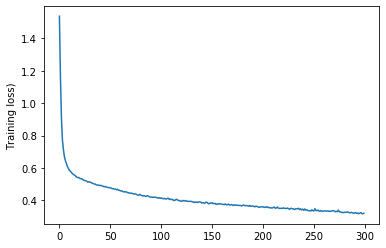

In [30]:
plt.plot(range(len(loss_train[0:300])), loss_train[0:300])
plt.ylabel('Training loss)')
plt.show()

In [ ]:
print(loss_train[0:300])

In [ ]:
print(prev_vector[:,0])

In [ ]:
print(c)
print(c_i[0]-c)
#print(c_i_plus)

In [ ]:
print(args.local_ep)
print(prev_vector)

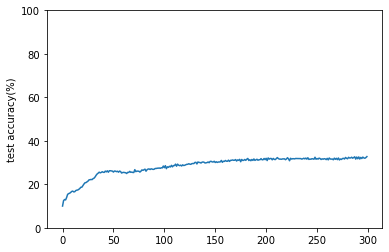

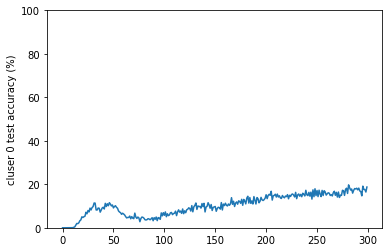

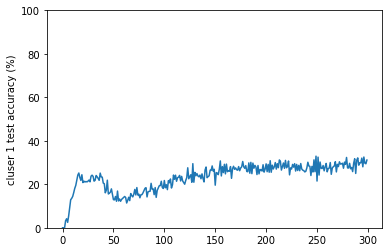

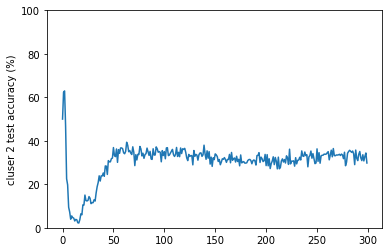

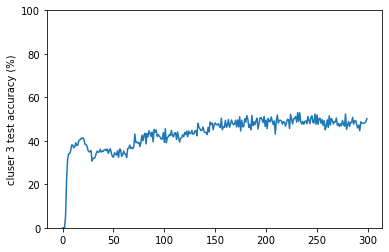

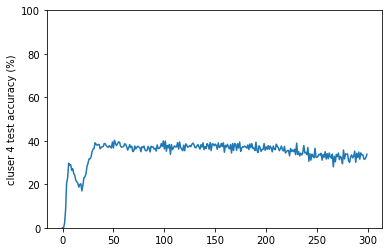

In [31]:
step=300
plt.ylim(0,100)
plt.plot(range(len(acc_test_arr[0:step])), acc_test_arr[0:step])
plt.ylabel('test accuracy(%)')
plt.show()
plt.ylim(0,100)
plt.plot(range(len(cluster_0_acc[0:step])), cluster_0_acc[0:step])
plt.ylabel('cluser 0 test accuracy (%)')
plt.show()
plt.ylim(0,100)
plt.plot(range(len(cluster_1_acc[0:step])), cluster_1_acc[0:step])
plt.ylabel('cluser 1 test accuracy (%)')
plt.show()
plt.ylim(0,100)
plt.plot(range(len(cluster_2_acc[0:step])), cluster_2_acc[0:step])
plt.ylabel('cluser 2 test accuracy (%)')
plt.show()
plt.ylim(0,100)
plt.plot(range(len(cluster_3_acc[0:step])), cluster_3_acc[0:step])
plt.ylabel('cluser 3 test accuracy (%)')
plt.show()
plt.ylim(0,100)
plt.plot(range(len(cluster_4_acc[0:step])), cluster_4_acc[0:step])
plt.ylabel('cluser 4 test accuracy (%)')

plt.show()

In [32]:
cluster_0=[]
cluster_1=[]
cluster_2=[]
cluster_3=[]
cluster_4=[]
acc_test=[]
for i in range(300):
    cluster_0.append(float(cluster_0_acc[i]))
    cluster_1.append(float(cluster_1_acc[i]))
    cluster_2.append(float(cluster_2_acc[i]))
    cluster_3.append(float(cluster_3_acc[i]))
    cluster_4.append(float(cluster_4_acc[i]))
    acc_test.append(float(acc_test_arr[i]))
print(cluster_0)
print("gap")
print(cluster_1)
print("gap")
print(cluster_2)
print("gap")
print(cluster_3)
print("gap")
print(cluster_4)
#print(acc_test)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05000000074505806, 0.20000000298023224, 0.4000000059604645, 1.25, 2.0, 1.899999976158142, 2.299999952316284, 3.25, 3.6500000953674316, 5.050000190734863, 4.75, 5.099999904632568, 5.300000190734863, 7.150000095367432, 6.449999809265137, 7.949999809265137, 7.300000190734863, 9.050000190734863, 8.199999809265137, 9.300000190734863, 9.75, 11.399999618530273, 11.350000381469727, 8.199999809265137, 8.199999809265137, 9.100000381469727, 9.0, 7.199999809265137, 8.199999809265137, 9.149999618530273, 9.449999809265137, 8.649999618530273, 11.25, 9.800000190734863, 11.050000190734863, 10.149999618530273, 11.550000190734863, 10.899999618530273, 10.050000190734863, 10.5, 9.149999618530273, 9.800000190734863, 10.149999618530273, 9.399999618530273, 9.0, 7.75, 7.25, 6.949999809265137, 6.199999809265137, 6.699999809265137, 6.349999904632568, 5.900000095367432, 5.150000095367432, 4.550000190734863, 4.75, 4.75, 5.400000095367432, 4.150000095367432, 5.15

In [ ]:
print(sum(cluster_0))
print(sum(cluster_1))
print(sum(cluster_2))
print(sum(cluster_3))
print(sum(cluster_4))